# Text Mining Project Work (Team 5)
### Damon Caron, Jovan Jezdic, Giovanni Duca, Pierpaolo Foddai, Alice Williams

**Opinion Mining on Amazon Reviews with Logistic Regression, Multi-Layer Perceptron, and Prompting**

_Prof. Gianluca Moro, Prof. Giacomo Frisoni – DISI, University of Bologna_

**Bologna Business School** - Alma Mater Studiorum Università di Bologna

## Instructions
- 🤝 The provided exercises must be collectively executed by the students of **Team 5**.
- 🚩 At the end, the file must contain all the required results (as **code cell outputs**) along with all the **commands necessary to reproduce them**.
- 💬 **All choices made during the implementation must be thoroughly commented on**. Students should clearly explain the inner workings of their solutions and justify their approaches. The documentation quality must be on par with the notebooks tackled during lessons. Feel free to add Markdown cells for discussions.
- 📚 **You are allowed to consult the teaching material, search the Web for quick reference, and use LLMs**.
- ⛔ **It is strictly forbidden to communicate with other teams**. If you need clarification about the exercises, ask the teacher directly.
- 📊 **Each exercise has a specific score value**, as indicated in brackets *[X points]*. Your final score will be based on:
    - **Correctness of the Output** (Does the code produce the expected results?)
    - **Quality of the Code** (Is the code efficient, clean, well-structured, and readable?)
    - **Documentation and Justification** (Are choices clearly explained? Is the implementation well-commented and easy to follow?)

---

- ⏰ The **submission deadline** is **March 27th, 2026 at 23:59 (UTC+1)**.
- 📨 When the work is complete—any time before the deadline—**one team member must send the notebook file** (.ipynb extension) **via email to the lab teacher** (giacomo.frisoni@unibo.it). The email subject must be: "**[BBS Teamwork] Team 1**". All other team members must be included in CC in the email.
- ⚖️ Please note that no separate discussion or presentation is planned for this teamwork. The project will receive a **collective assessment**, meaning that all members of the team will receive the same mark. **This evaluation will be complemented and mediated through the individual exam (the theory quiz)**, which will contribute to determining the final assessment.

## Setup

Run the following to download the necessary files.

In [ ]:
import os
from urllib.request import urlretrieve

In [ ]:
def download(file, url):
    if not os.path.exists(file):
        urlretrieve(url, file)

In [ ]:
download("Magazine_Subscriptions.json.gz", "https://www.dropbox.com/s/g6om8q8c8pvirw8/Magazine_Subscriptions.json.gz?dl=1")

## Exercises

Please read the entire exercise track before starting the implementation.

**1) Load the dataset** *[1 point]*
- In the `Magazine_Subscriptions.json.gz` file, we provide a dataset composed of several reviews posted on Amazon.com about Magazine Subscriptions.
- That file is a compressed .gzip, so you must open it using a .gzip decompression library.
- Each review is labeled with a score between 1 and 5 stars (represented by the ```overall``` feature).
- The text of each review is represented by the ```reviewText``` feature, which will be our input data along with the ```overall``` one.
- Load the dataset by putting it in a new Pandas dataframe. The data is stored as a JSON file, so you will have to use a Python package to load JSON data into a variable.

In [ ]:
# Installs needed for last section of notebook
# !pip install torch==2.5.1
# !pip install torchvision==0.20.1 --no-deps # Install compatible torchvision
# !pip install transformers==4.49.0
# !pip install accelerate==1.3.0
# !pip install tqdm
# !pip install bitsandbytes

In [ ]:
# !pip install wordcloud

import gzip
import json
import joblib
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import warnings
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import chi2_contingency
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig

In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_json('Magazine_Subscriptions.json.gz', compression='gzip', lines=True) # load dataset
df = df[['reviewText', 'overall']] # input data only reviewText and overall
df.head(10)

,reviewText,overall
0,"for computer enthusiast, MaxPC is a welcome si...",5
1,Thank god this is not a Ziff Davis publication...,5
2,Antiques Magazine is a publication made for an...,3
3,This beautiful magazine is in itself a work of...,5
4,A great read every issue.,5
5,This magazine was great for the times but as w...,3
6,I've read Maximum PC (MPC) for many years. The...,5
7,We ordered this magazine for our grandson (the...,5
8,I have subscribed to the nook version for a fe...,4
9,"I'm old, and so is my computer. Any advice th...",4


**2) Understand the dataset** *[3 points]*

Once the dataset is loaded, perform an initial exploration to understand its structure and characteristics.
- Print the total number of reviews in the dataset.
- Display the first 10 rows of the dataframe to examine its contents.
- Compute and print the minimum, average, and maximum lengths (in characters) of the reviews.
- Display the distribution of labels to understand the frequency of each star rating. A bar chart is highly recommended for clarity.
- Visualize the most commonly used words in a word cloud, excluding stopwords. Research and choose the most suitable Python library for generating an informative and aesthetically appealing visualization.

Total number of reviews: 89689

First 10 rows of dataset:
                                          reviewText  overall
0  for computer enthusiast, MaxPC is a welcome si...        5
1  Thank god this is not a Ziff Davis publication...        5
2  Antiques Magazine is a publication made for an...        3
3  This beautiful magazine is in itself a work of...        5
4                          A great read every issue.        5
5  This magazine was great for the times but as w...        3
6  I've read Maximum PC (MPC) for many years. The...        5
7  We ordered this magazine for our grandson (the...        5
8  I have subscribed to the nook version for a fe...        4
9  I'm old, and so is my computer.  Any advice th...        4

Review Length Statistics (Characters):
Minimum: 1
Average: 242.8616
Maximum: 28100




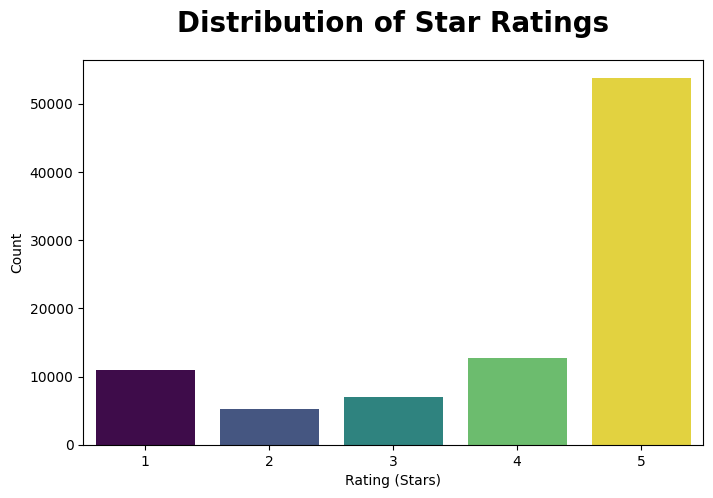

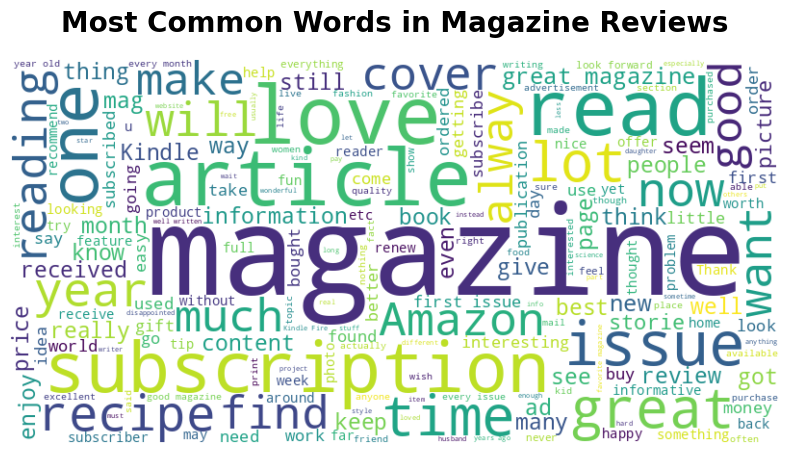

In [ ]:
print("Total number of reviews:", len(df)) # print total number of reviews in dataset
print()
print("First 10 rows of dataset:")
print(df.head(10)) # display first 10 rows of df

print()
df['review_len'] = df['reviewText'].astype(str).apply(len) # handle potential NaN values by converting to string first
print("Review Length Statistics (Characters):")
print("Minimum:", df['review_len'].min()) # compute and print minimum length in characters of reviews
print("Average:", round(df['review_len'].mean(),4)) # compute and print average length in characters of reviews
print("Maximum:", df['review_len'].max()) # compute and print maximum length in characters of reviews
print()
print()

plt.figure(figsize=(8, 5)) # display distribution of labels to understand frequency of each star rating
sns.countplot(x='overall', data=df, hue='overall', palette='viridis', legend=False)
plt.title('Distribution of Star Ratings', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
plt.show()
print()
print()

text = " ".join(review for review in df.reviewText.astype(str)) # combine all reviews into one massive string
wordcloud = WordCloud(background_color='white', stopwords=STOPWORDS, width=800, height=400, colormap='viridis').generate(text) # generate cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Magazine Reviews', fontsize=20, fontweight='bold', pad=20)
plt.show()

**3) Create a class-balanced dataset** *[2 points]*

Balance the dataset based on the `overall` feature (e.g., undersampling, oversampling). Justify your approach.

Number of reviews dropped: 3392

Examples of dropped reviews:
      reviewText  overall
2939       GREAT        5
22534         OK        3
47565  Excellent        5
57778    All ads        2
34819    Well...        1
75529    Like it        5
55136    Love it        5
8953    canceled        5
75634    LOVE!!!        5
69641     thanks        5

Number of dropped reviews per class:
overall
1     117
2      56
3     214
4     477
5    2528
Name: count, dtype: int64


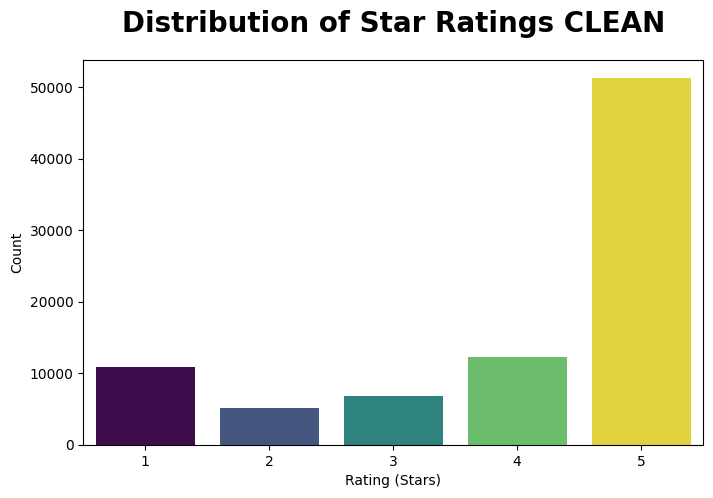

In [ ]:
# approach for balancing the dataset: mixture of undersampling and oversampling
# first - clean the dataset

df['review_len'] = df['reviewText'].astype(str).str.len() # calculate length of each review as a string

deleted_reviews = df[df['review_len'] < 10] # isolate reviews that are "not informative enough" (less than 10 characters)

print(f"Number of reviews dropped: {len(deleted_reviews)}")
print("\nExamples of dropped reviews:")

if len(deleted_reviews) > 0: # display a random sample of 10 dropped reviews to see what we are losing
    print(deleted_reviews[['reviewText', 'overall']].sample(min(10, len(deleted_reviews)), random_state=42))

df_clean = df[df['review_len'] >= 10] # keep only the "informative" reviews (10 characters or more)

print("\nNumber of dropped reviews per class:")
print(deleted_reviews['overall'].value_counts().sort_index())

plt.figure(figsize=(8, 5)) # display distribution of labels to understand frequency of each star rating
sns.countplot(x='overall', data=df_clean, hue='overall', palette='viridis', legend=False)
plt.title('Distribution of Star Ratings CLEAN', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
plt.show()

In [ ]:
# approach for balancing the dataset: mixture of undersampling and oversampling
# second - balance the classes

target_count = df_clean[df_clean['overall'] == 4].shape[0] # define target count based on frequency of class 4
print(f"Target count for all classes: {target_count}\n")

balanced_dfs = []

for rating in df_clean['overall'].unique(): # loop through each unique star rating and resample to match target_count
    class_df = df_clean[df_clean['overall'] == rating]

    if len(class_df) < target_count:
        resampled_df = class_df.sample(n=target_count, replace=True, random_state=42)  # oversample with replacement for minority classes (1, 2, 3)
        print(f"Class {rating}: Oversampled from {len(class_df)} to {target_count}")

    elif len(class_df) > target_count:
        resampled_df = class_df.sample(n=target_count, replace=False, random_state=42) # randomly undersample w/o replacement for majority class (5)
        print(f"Class {rating}: Undersampled from {len(class_df)} to {target_count}")

    else:
        resampled_df = class_df # keep class 4 the same
        print(f"Class {rating}: Kept at {target_count}")

    balanced_dfs.append(resampled_df)

df_balanced = pd.concat(balanced_dfs) # concatenate everything back together

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True) # shuffle final balanced dataset to ensure randomized order

Target count for all classes: 12199

Class 5: Undersampled from 51262 to 12199
Class 3: Oversampled from 6757 to 12199
Class 4: Kept at 12199
Class 2: Oversampled from 5167 to 12199
Class 1: Oversampled from 10912 to 12199


**4) Preprocess the dataset** *[1 point]*

- Cast the `reviewText` column to unicode string.
- Choose only the attributes labeled as ```reviewText``` and ```overall``` from the dataset, and place them into a dataframe.
- Remove from the dataframe the reviews rated with 3 stars.
- Add a `label` column to the DataFrame whose value is `"pos"` for reviews with 4 stars, `"very_pos"` for 5-rated reviews, `"neg"` for reviews with 2 stars, and `"very_neg"` for 1-rated reviews.

In [ ]:
df['reviewText'] = df['reviewText'].astype(str) # cast reviewText column to unicode string

df_balanced = df_balanced[['reviewText', 'overall']] # choose only required attributes

df_filtered = df_balanced[df_balanced['overall'] != 3].copy() # remove reviews rated with 3 stars

label_mapping = {1: 'very_neg', 2: 'neg', 4: 'pos', 5: 'very_pos'} # add 'label' column using a mapping dictionary
df_filtered['label'] = df_filtered['overall'].map(label_mapping)

df_final = df_filtered[['reviewText', 'label']] # drop 'overall' column, keeping only input and target

print("First 10 rows of filtered dataset:")
print(df_final.head(10)) # verify final structure
print("\nFinal label distribution:")
print(df_final['label'].value_counts())

First 10 rows of filtered dataset:
                                          reviewText     label
0          Quality magazine at just the right price.       pos
1  I love that this magazine covers everything fr...  very_pos
2  Very confusing, and after 3 phone calls finall...  very_neg
3  I have not been able to open this magazine. Wh...  very_neg
4  I love this magazine... I do lots of this kind...  very_pos
5  Harper's has been in business since 1850 and h...       pos
6  Wow, saved a bundle ordering my renewal throug...  very_pos
7  This is in the wrong category. It should be in...  very_neg
8  Did not like this particular magazine on Kindl...       neg
9  The recipes and articles are good - I find I a...       pos

Final label distribution:
label
pos         12199
very_pos    12199
very_neg    12199
neg         12199
Name: count, dtype: int64


**5) Split the dataset** *[2 points]*

Split the dataset randomly into train-eval-test splits using a 80-10-10 ratio and stratifying by the `label` variable.

Stratification ensures that both the training and test sets contain a proportional mix of all class labels.

In [ ]:
X = df_final['reviewText'] # separate features (X) and the target labels (y)
y = df_final['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y) # split 1 ("temporary"): 80% training, 20% test

X_eval, X_test, y_eval, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp) # split 2: split test set from split 1 in half to get 10% eval and 10% test

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X):.0%})") # verify splits and their stratification
print(f"Evaluation set size: {len(X_eval)} ({len(X_eval)/len(X):.0%})")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X):.0%})\n")

print("Class distribution in Training set:")
print(y_train.value_counts(normalize=True))

Training set size: 39036 (80%)
Evaluation set size: 4880 (10%)
Test set size: 4880 (10%)

Class distribution in Training set:
label
very_neg    0.25
very_pos    0.25
neg         0.25
pos         0.25
Name: proportion, dtype: float64


**6) Represent documents with TF-IDF** *[1 point]*

Create a TF-IDF vector space model excluding words appearing in less than 3 documents and using bigrams in addition to single words.

Then, extract the document-term matrix for them.

In [ ]:
tfidf = TfidfVectorizer(min_df=3, ngram_range=(1, 2)) # initialize TF-IDF vectorizer to: exclude words appearing in less than 3 documents and use unigrams (1) and bigrams (2)

X_train_tfidf = tfidf.fit_transform(X_train) # fit and transform training data

X_eval_tfidf = tfidf.transform(X_eval) # tranform evaluation and test data
X_test_tfidf = tfidf.transform(X_test)

print(f"Training matrix shape: {X_train_tfidf.shape}") # verify shape of new document-term matrix
print(f"Evaluation matrix shape: {X_eval_tfidf.shape}")
print(f"Test matrix shape: {X_test_tfidf.shape}")
print(f"Total vocabulary size (features): {X_train_tfidf.shape[1]}")

Training matrix shape: (39036, 128411)
Evaluation matrix shape: (4880, 128411)
Test matrix shape: (4880, 128411)
Total vocabulary size (features): 128411


**7) Train a logistic regressor** *[3 points]*

Train a logistic regressor classifier using the representation created above.

🔄 Run a GridSearch to find the hyperparmaters that allow the network to better generalize on the eval set.

In [ ]:
X_train_eval_tfidf = sp.vstack((X_train_tfidf, X_eval_tfidf)) # combine train and eval sets into one large dataset
y_train_eval = pd.concat([y_train, y_eval])

test_fold = np.concatenate([np.full(X_train_tfidf.shape[0], -1),np.full(X_eval_tfidf.shape[0], 0)])
ps = PredefinedSplit(test_fold) # create PredefinedSplit array: -1 means row is in train set and 0 means row is in eval set

param_grid = {'C': [0.1, 1.0, 10.0],  'solver': ['liblinear', 'lbfgs'], 'max_iter': [1000]} # define hyperparameter grid: C = regularization strength, solver = algorithms to use in optimization problem

log_reg = LogisticRegression(random_state=42) # initialize model and GridSearchCV
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=ps, scoring='accuracy', n_jobs=-1, verbose=1)

print("Starting GridSearch...")
grid_search.fit(X_train_eval_tfidf, y_train_eval) # run GridSearchCV

best_log_reg = grid_search.best_estimator_ # extract best model
print("\nBest hyperparameters found on the Eval set:")
print(grid_search.best_params_)
print(f"Best Eval Set Accuracy: {grid_search.best_score_:.4f}")

Starting GridSearch...
Fitting 1 folds for each of 6 candidates, totalling 6 fits

Best hyperparameters found on the Eval set:
{'C': 10.0, 'max_iter': 1000, 'solver': 'liblinear'}
Best Eval Set Accuracy: 0.7619


**8) Evaluate the logistic regressor** *[2 points]*

- Measure the accuracy of the best-performing classifier (based on the evaluation set) on the test set.
- Get the model predictions and print the confusion matrix.

Logistic Regression Test Set Accuracy: 0.7754


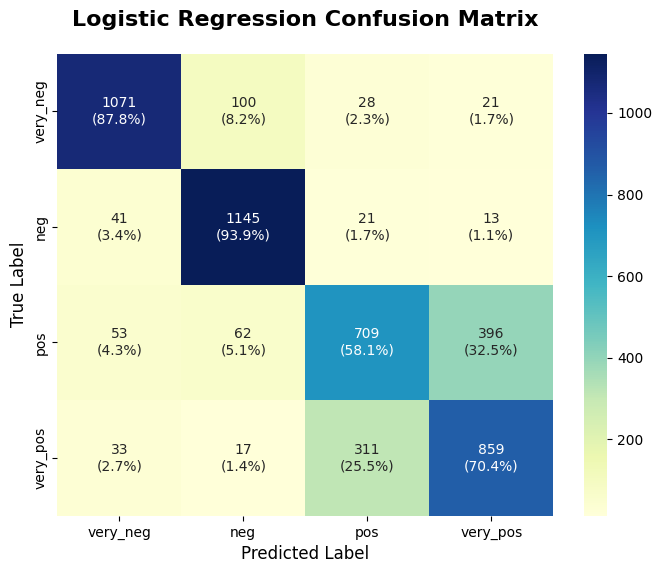

In [ ]:
y_pred_log_reg = best_log_reg.predict(X_test_tfidf) # generate predictions on unseen test set

test_accuracy = accuracy_score(y_test, y_pred_log_reg) # calculate accuracy
print(f"Logistic Regression Test Set Accuracy: {test_accuracy:.4f}")

ordered_labels = ['very_neg', 'neg', 'pos', 'very_pos'] # define logical, ordinal order of our sentiments

cm = confusion_matrix(y_test, y_pred_log_reg, labels=ordered_labels) # compute confusion matrix using our explicit order

cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # compute row-wise percentages (recall)

annot_labels = [f"{count}\n({pct:.1%})" for count, pct in zip(cm.flatten(), cm_percentages.flatten())] # create custom annotation array (counts + percentages)
annot_labels = np.asarray(annot_labels).reshape(cm.shape)

plt.figure(figsize=(8, 6)) # plot heatmap using our explicit order for x- and y- ticks
sns.heatmap(cm, annot=annot_labels, fmt='', cmap='YlGnBu', xticklabels=ordered_labels, yticklabels=ordered_labels  )
plt.title('Logistic Regression Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

**9) Train a MLP network** *[5 points]*

Train a Multi-Layer Perceptron model using the document-term representation built in point (6).

🔄 Perform in-depth ablations (e.g., number and size of hidden layers, non-linear activation functions, regularization techniques) to maximize eval set accuracy.

Document your choices and results, analyzing the strengths and weaknesses of different implementations.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/Colab Notebooks/BBS/Text Mining/' # define save directory in your Google Drive
os.makedirs(save_dir, exist_ok=True)

model_filename = os.path.join(save_dir, 'best_mlp_model.joblib') # define the exact file paths
encoder_filename = os.path.join(save_dir, 'label_encoder.joblib')

model_loaded = False # initialize safety flag

if os.path.exists(model_filename) and os.path.exists(encoder_filename): # check if files exist
    print("Saved files found in Google Drive! Loading the trained model and encoder...")
    best_mlp = joblib.load(model_filename)
    le = joblib.load(encoder_filename)
    model_loaded = True
    print("Model loaded successfully. You can SKIP the next cell and proceed to evaluation!")
else:
    print("No saved model found in Google Drive. Please run the next cell to train.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved files found in Google Drive! Loading the trained model and encoder...
Model loaded successfully. You can SKIP the next cell and proceed to evaluation!


In [ ]:
# !!!!!! READ ME !!!!!!!!
# !!!!!!!!! ONLY RUN THIS HEAVY TRAINING BLOCK IF THE MODEL WASN'T LOADED IN THE PREVIOUS CELL !!!!!!!!

if not model_loaded:
    print("Preparing to train the MLP...")

    from sklearn.neural_network import MLPClassifier
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder() # encode string labels into integers
    y_train_int = le.fit_transform(y_train)
    y_eval_int = le.transform(y_eval)

    y_train_eval_int = np.concatenate([y_train_int, y_eval_int]) # combine integer labels for GridSearchCV

    mlp = MLPClassifier(early_stopping=True, validation_fraction=0.1, n_iter_no_change=5, max_iter=500, random_state=42) # initialize MLP model (optimized for speed)

    param_grid_mlp = {'hidden_layer_sizes': [(50,), (100,), (50, 25)], 'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001]} # define Ablation Grid

    grid_search_mlp = GridSearchCV(estimator=mlp, param_grid=param_grid_mlp, cv=ps, scoring='accuracy', n_jobs=-1, verbose=3) # initialize GridSearchCV (optimized for speed and visibility)

    print("Starting MLP GridSearch (Multiply the first fit time by 12 for your total ETA...)")  # run GridSearchCV
    grid_search_mlp.fit(X_train_eval_tfidf, y_train_eval_int)

    best_mlp = grid_search_mlp.best_estimator_ # extract best model
    print("\nBest MLP architecture found on the Eval set:")
    print(grid_search_mlp.best_params_)
    print(f"Best Eval Set Accuracy: {grid_search_mlp.best_score_:.4f}")

    joblib.dump(best_mlp, model_filename) # SAVE MODEL AND ENCODER TO GOOGLE DRIVE
    joblib.dump(le, encoder_filename)
    print(f"\n Model and encoder permanently saved to Google Drive at '{save_dir}'!")

    model_loaded = True # update flag so you don't accidentally run it again

else:
    print("Model is already loaded in memory. Training skipped!")

Model is already loaded in memory. Training skipped!


**10) Evaluate the MLP network** *[2 points]*

- Measure the accuracy of the best-performing classifier (based on the evaluation set) on the test set.
- Get the model predictions and print the confusion matrix.

Generating predictions on the test set...
ML Text Mining Project P Test Set Accuracy: 0.7717


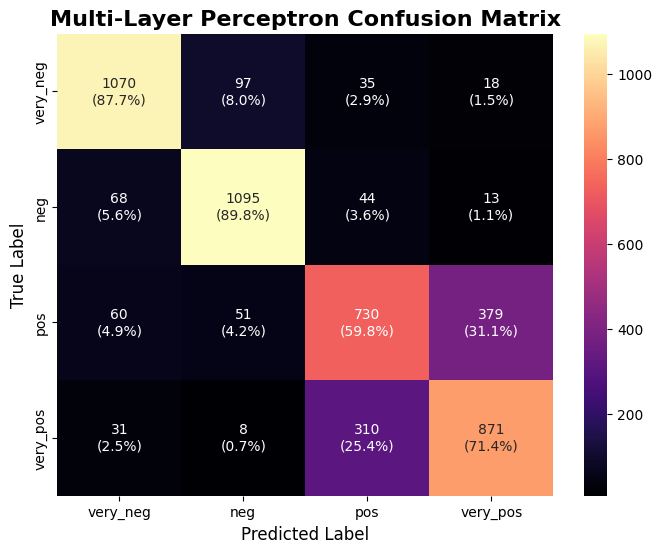

In [ ]:
print("Generating predictions on the test set...")
y_pred_mlp_int = best_mlp.predict(X_test_tfidf) # generate integer predictions on unseen test set

y_pred_mlp = le.inverse_transform(y_pred_mlp_int) # decode integers back into string labels using LabelEncoder

test_accuracy_mlp = accuracy_score(y_test, y_pred_mlp) # calculate and print overall accuracy
print(f"ML Text Mining Project P Test Set Accuracy: {test_accuracy_mlp:.4f}")

ordered_labels = ['very_neg', 'neg', 'pos', 'very_pos'] # define logical, ordinal order of our sentiments

cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=ordered_labels) # compute confusion matrix using our explicit order

cm_percentages_mlp = cm_mlp.astype('float') / cm_mlp.sum(axis=1)[:, np.newaxis] # compute row-wise percentages (recall)

annot_labels_mlp = [f"{count}\n({pct:.1%})" for count, pct in zip(cm_mlp.flatten(), cm_percentages_mlp.flatten())] # create custom annotation array (counts + percentages)
annot_labels_mlp = np.asarray(annot_labels_mlp).reshape(cm_mlp.shape)

plt.figure(figsize=(8, 6)) # plot heatmap
sns.heatmap(cm_mlp, annot=annot_labels_mlp, fmt='', cmap='magma', xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.title('Multi-Layer Perceptron Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

**11) Compare Logistic Regressor and MLP predictions** *[2 points]*

Compare the test set predictions of the Logistic Regressor and MLP models.

Use the Chi-Square test to determine whether the two models produce significantly different predictions at a 95% confidence level (p-value ≤ 0.05 indicates a significant difference).

Hint: convert predictions into integer arrays for comparison.

Compute the p-value using the provided `chi2_pval`, inputting the arrays containing the predicted labels from the two models as well as the true labels.

```
chi2_pval(model1_predictions, model2_predictions, y_test)
```

In [ ]:
def chi2_pval(p1, p2, y_test):
    model1_errors = p1 != y_test
    model2_errors = p2 != y_test

    contingency_table = pd.crosstab(model1_errors, model2_errors) # construct contingency table

    contingency_table.index = ['LogReg Correct', 'LogReg Wrong'] # rename False (Correct) and True (Wrong) for both models
    contingency_table.columns = ['MLP Correct', 'MLP Wrong']

    contingency_table.index.name = None # remove 'row_0' and 'col_0' axis names
    contingency_table.columns.name = None

    print("Contingency Table of Model Performance:")
    print("-" * 40)
    print(contingency_table)
    print("-" * 40)

    _, p_value = chi2_contingency(contingency_table, correction=False)[:2] # calculate chi-square test statistic and p-value

    return p_value

In [ ]:
label_map = {'very_neg': 0, 'neg': 1, 'pos': 2, 'very_pos': 3} # define label mapping to match types

p1_int = np.array([label_map[label] for label in y_pred_log_reg]) # convert to consistent integer arrays for function
p2_int = np.array([label_map[label] for label in y_pred_mlp])
y_test_int = y_test.map(label_map).values

print("Generating Contingency Table of Errors...")
p_value = chi2_pval(p1_int, p2_int, y_test_int) # call provided function

print(f"\nStatistical Results:")
print(f"Chi-Square p-value: {p_value:.5f}") # interpret results

alpha = 0.05
if p_value <= alpha:
    print(f"Result: Significant (p <= {alpha})")
    print("Interpretation: The models' errors are significantly different. "
          "One model is statistically performing better/differently than the other.")
else:
    print(f"Result: Not Significant (p > {alpha})")
    print("Interpretation: There is no statistical difference in how these models fail. "
          "Any difference in accuracy is likely due to random chance.")

Generating Contingency Table of Errors...
Contingency Table of Model Performance:
----------------------------------------
                MLP Correct  MLP Wrong
LogReg Correct         3597        187
LogReg Wrong            169        927
----------------------------------------

Statistical Results:
Chi-Square p-value: 0.00000
Result: Significant (p <= 0.05)
Interpretation: The models' errors are significantly different. One model is statistically performing better/differently than the other.


**12) Evaluate a Large Language Model** *[6 points]*

Take a Large Language Model of your choice.

Use prompting to classify each review in the test set into one of the following categories: "pos", "very_pos", "neg", "very_neg".

Analyze and interpret the results

In [ ]:
import gc

# Delete old objects if they exist
if 'model' in locals(): del model
gc.collect()
torch.cuda.empty_cache()

torch.random.manual_seed(0)
model_path = "microsoft/Phi-4-mini-instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_path, padding_side='left')

model = torch.compile(model, mode="reduce-overhead")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
from transformers import LogitsProcessor, LogitsProcessorList

# To force output into one of our valid categories
# Necessary to protect against model hallucinations
allowed_words = ["pos", "very_pos", "neg", "very_neg"]
allowed_token_ids = []
for word in allowed_words:
    ids = tokenizer.encode(word, add_special_tokens=False)
    allowed_token_ids.extend(ids)

class ForceSentimentProcessor(LogitsProcessor):
    def __init__(self, allowed_ids):
        self.allowed_ids = list(set(allowed_ids)) # Unique IDs only
    def __call__(self, input_ids, scores):
        mask = torch.full_like(scores, -float("inf"))
        mask[:, self.allowed_ids] = 0
        return scores + mask

logits_processor = LogitsProcessorList([ForceSentimentProcessor(allowed_token_ids)])

In [ ]:
# Set up few-shot-prompting
def prompt_generator(df):
    prompts = []
    system_prefix = (
        "<|system|>\nYou are a sentiment classifier. You must respond with EXACTLY one of these four labels: 'pos', 'very_pos', 'neg', 'very_neg'. Do not explain. Do not use other labels.<|end|>\n"
        "<|user|>\nText: 'Amazing product!'\nSentiment: <|end|>\n<|assistant|>\nvery_pos<|end|>\n"
        "<|user|>\nText: 'It works.'\nSentiment: <|end|>\n<|assistant|>\npos<|end|>\n"
        "<|user|>\nText: 'Waste of money.'\nSentiment: <|end|>\n<|assistant|>\nvery_neg<|end|>\n"
    )

    for review in df.astype(str):
        # Model should get sentiment within 200 tokens, protect against truncation
        clean_review = review.replace("\n", " ").replace("\r", " ").strip()
        truncated_review = clean_review[:200]
        prompts.append(f"{system_prefix}<|user|>\nReview: '{truncated_review}'\nCategory:<|end|>\n<|assistant|>\n")

    return prompts

X_test_copy = X_test.copy()
# Sort by review length to prevent unnecessary padding
X_test_copy = X_test_copy.reindex(X_test_copy.str.len().sort_values().index)

prompts = prompt_generator(X_test_copy)

tokenizer.pad_token = tokenizer.eos_token

# Pre-tokenize everything
print("Tokenizing all reviews...")
encodings = tokenizer(text=prompts,
                      padding=True,
                      truncation=True,
                      max_length=512,
                      return_tensors="pt").to("cuda")

results = []
batch_size = 16

stop_token_ids = [
    tokenizer.eos_token_id,
    tokenizer.encode("\n", add_special_tokens=False)[-1],
    tokenizer.convert_tokens_to_ids("<|end|>")
]

# Classify reviews in batches
for i in tqdm(range(0, len(prompts), batch_size)):
    # Grab a slice of the pre-tokenized tensors
    batch_input_ids = encodings.input_ids[i:i+batch_size].to("cuda")
    batch_attention_mask = encodings.attention_mask[i:i+batch_size].to("cuda")

    with torch.inference_mode():
      outputs = model.generate(
          input_ids=batch_input_ids,
          attention_mask=batch_attention_mask,
          max_new_tokens=2,
          do_sample=False,
          logits_processor=logits_processor, # THIS IS THE KEY
          pad_token_id=tokenizer.pad_token_id,
          eos_token_id=tokenizer.eos_token_id
      )

    # Decode only the new tokens
    decoded = tokenizer.batch_decode(outputs[:, batch_input_ids.shape[1]:], skip_special_tokens=True)
    results.extend([d.strip().lower() for d in decoded])

Tokenizing all reviews...


  0%|          | 0/305 [00:00<?, ?it/s]

In [ ]:
# Programatically select one of our valid categories if model output has incorrect formatting
valid = {'pos', 'very_pos', 'neg', 'very_neg'}
# If a result contains one of our keywords, map it to that keyword
cleaned_results = []
for r in results:
    found = False
    for v in sorted(valid, key=len, reverse=True): # Check 'very_pos' before 'pos'
        if v in r:
            cleaned_results.append(v)
            found = True
            break
    if not found:
        cleaned_results.append('unknown')

# Verify results only contain expected values
print(pd.Series(cleaned_results).unique())

['pos' 'very_pos' 'very_neg' 'neg']


--- LLM Performance ---
Accuracy:  0.4742
Precision: 0.4738
F1 Score:  0.4336



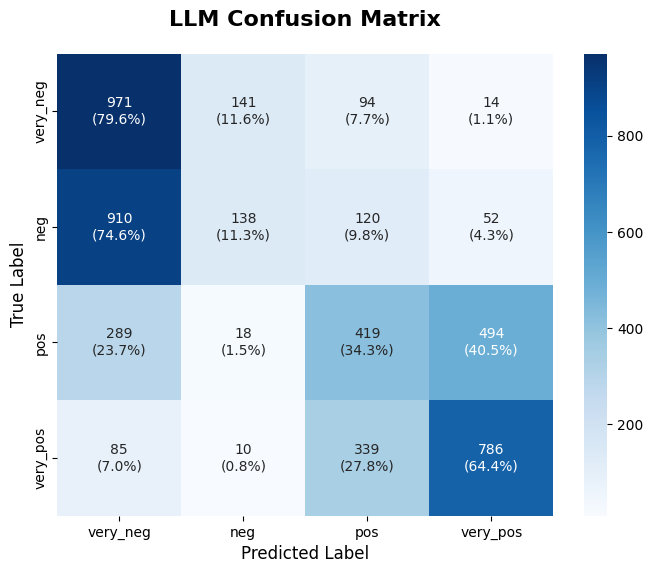


--- Models Comparison ---


,Model,Accuracy,Precision,F1 Score
0,Logistic Regression,0.7754,0.7721,0.7726
1,MLP,0.7717,0.7696,0.7702
2,LLM (Phi-4-mini),0.4742,0.4738,0.4336


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_llm = pd.DataFrame({
    'reviewText': X_test_copy,
    'true_label': y_test.loc[X_test_copy.index], # Align true labels using index
    'llm_label': cleaned_results
})

# Prompt-generated labels eval
llm_accuracy = accuracy_score(df_llm['true_label'], df_llm['llm_label'])
llm_p, llm_r, llm_f1, _ = precision_recall_fscore_support(
    df_llm['true_label'],
    df_llm['llm_label'],
    average='weighted',
    labels=['very_neg', 'neg', 'pos', 'very_pos']
)

print("--- LLM Performance ---")
print(f"Accuracy:  {llm_accuracy:.4f}")
print(f"Precision: {llm_p:.4f}")
print(f"F1 Score:  {llm_f1:.4f}\n")

# Confusion Matrix
ordered_labels = ['very_neg', 'neg', 'pos', 'very_pos']
cm_llm = confusion_matrix(df_llm['true_label'], df_llm['llm_label'], labels=ordered_labels)

cm_percentages_llm = cm_llm.astype('float') / cm_llm.sum(axis=1)[:, np.newaxis]
annot_labels_llm = [f"{count}\n({pct:.1%})" for count, pct in zip(cm_llm.flatten(), cm_percentages_llm.flatten())]
annot_labels_llm = np.asarray(annot_labels_llm).reshape(cm_llm.shape)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_llm, annot=annot_labels_llm, fmt='', cmap='Blues', xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.title('LLM Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Comparison with Logistic Regression and MLP
print("\n--- Models Comparison ---")
# Calculate metrics for existing models using the same weighted average for consistency
lr_p, lr_r, lr_f1, _ = precision_recall_fscore_support(y_test, y_pred_log_reg, average='weighted', labels=ordered_labels)
lr_acc = accuracy_score(y_test, y_pred_log_reg)

mlp_p, mlp_r, mlp_f1, _ = precision_recall_fscore_support(y_test, y_pred_mlp, average='weighted', labels=ordered_labels)
mlp_acc = accuracy_score(y_test, y_pred_mlp)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'MLP', 'LLM (Phi-4-mini)'],
    'Accuracy': [lr_acc, mlp_acc, llm_accuracy],
    'Precision': [lr_p, mlp_p, llm_p],
    'F1 Score': [lr_f1, mlp_f1, llm_f1]
})

display(comparison_df.round(4))

SCREENSHOT OF RESULTS IN CASE NOT SHOWN IN CELL OUTPUT:
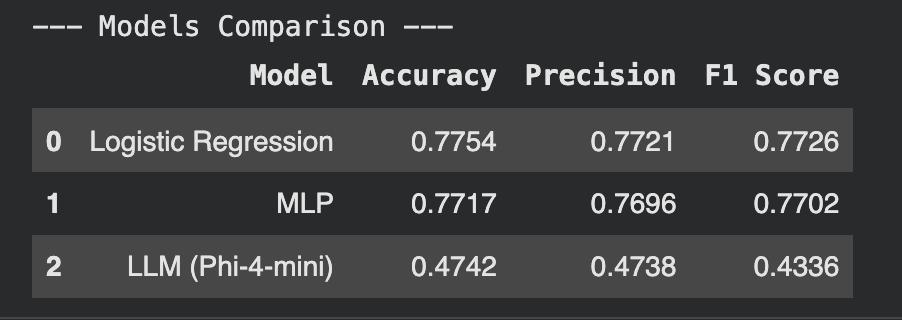

As we can see, the prompt-generated labels from Phi-4-mini perform far worse than dedicated Logistic Regression or Mulit-layer Perceptron models across all of the considered evaluation metrics. In general, phi-4-mini was able to correctly determine if a review was positve or negative, indicated by the strong diagonal *quadrants* on the confusion matrix, but it notably struggled on distinguishing a positive/negative review from a *very* positive/negative one.

We can rationalize this relative drop in performance due to the measures we had to take in order to download, store, and run an entire LLM all in memory in the first place: choosing a small 3B paramater model; compacting it further via 4-bit quantization as opposed to using the default 16-bit weights; requiring few-shot prompting in order to prevent mode collapse and hallucinations, which in turn drove us to truncating reviews in order to make efficient inferences.

Overall, asking such a small, compacted, non-specialized model via prompting is a much more roundabout and ineffective way of classifying reviews, especially when compared to more specialized models which were trained directly on the expected labels. Though, we can imagine that the results would be much more comparable if we provided the reviews instead to, for example, the latest version of Gemini Pro.

**(Optional)** *[1 extra point]*

Track your training and inference runs with [WandB](https://wandb.ai/) and share either a public link to the project or a generated report.
Make sure to assign meaningful and descriptive names to your runs to clearly distinguish different experiments.